# Notebook 08 — BERT vs RoBERTa: Polysemy Comparison

**Words:** bank · plant · bat · crane · seal · spring  
**Models:** bert-base-uncased · roberta-base  
**Metrics:** Self-Similarity · MEV · K-Means Silhouette

**Key question:**  
> Does BERT or RoBERTa produce more geometrically structured sense representations  
> for polysemous words, and do their layer-wise dynamics differ?


## Cell 1 — Imports

In [33]:
import sys
sys.path.append("..")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from transformers import BertTokenizer, BertModel, RobertaTokenizer, RobertaModel
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.extraction import load_word_contexts
from src.embeddings import get_word_embedding
from src.similarity import average_similarity
from src.mev import compute_mev

## Cell 2 — Configuration

In [27]:
TARGET_WORDS = ["bank", "plant", "spring"]

WORD_SENSES = {
    "bank":   ["river / terrain",  "financial institution"],
    "plant":  ["living organism",  "factory / industrial"],
    "spring": ["season",           "coil / mechanical"],
}

COLORS = plt.cm.tab10.colors
K           = 2     # senses per word
LAST_LAYER  = 12    # 0-indexed final transformer layer

## Cell 3 — Load Both Models

In [28]:
# BERT
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model     = BertModel.from_pretrained("bert-base-uncased",
                                           output_hidden_states=True)
bert_model.eval()

# RoBERTa
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model     = RobertaModel.from_pretrained("roberta-base",
                                                 output_hidden_states=True)
roberta_model.eval()

print("Both models loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Both models loaded.


## Cell 4 — Load Contexts

In [29]:
contexts_by_word = {}

for word in TARGET_WORDS:
    ctxs = load_word_contexts(word)
    contexts_by_word[word] = ctxs
    print(f"  [{word:>6}]  {len(ctxs)} contexts")

  [  bank]  56 contexts
  [ plant]  56 contexts
  [spring]  56 contexts


## Cell 5 — Embedding Extraction Helper

Embeddings for each model are extracted **once** per word.  
Self-similarity, MEV and clustering all read from the same cached list.


In [30]:
def extract_embeddings(contexts, word, tokenizer, model):
    """
    Returns list of N elements; each element is a list of 13 vectors (768-d).
    Invalid sentences (word not found after tokenization) are silently dropped.
    """
    embeddings = []
    for ctx in contexts:
        emb = get_word_embedding(ctx, word, tokenizer, model)
        if emb is not None:
            embeddings.append(emb)
    return embeddings


def compute_metrics(embeddings):
    """
    From a cached embedding list compute self-similarity and MEV per layer.
    No model calls — pure NumPy.
    """
    n_layers = len(embeddings[0])
    sim_curve, mev_curve = [], []
    for layer_idx in range(n_layers):
        vecs = np.array([emb[layer_idx] for emb in embeddings])
        sim_curve.append(average_similarity(vecs))
        mev_curve.append(compute_mev(vecs))
    return sim_curve, mev_curve


def cluster_at_layer(embeddings, layer_idx=LAST_LAYER, k=K):
    """K-Means + silhouette + PCA coords at a given layer."""
    vecs   = np.array([emb[layer_idx] for emb in embeddings])
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(vecs)
    sil    = silhouette_score(vecs, labels) if len(set(labels)) >= 2 else float("nan")
    pca    = PCA(n_components=2)
    coords = pca.fit_transform(vecs)
    var    = pca.explained_variance_ratio_
    return labels, coords, sil, var

## Cell 6 — Run Full Pipeline for Both Models

For each word:
1. Extract BERT embeddings once → compute sim, MEV, cluster
2. Extract RoBERTa embeddings once → compute sim, MEV, cluster


In [31]:
results = {}

for word in TARGET_WORDS:
    print(f"Processing '{word}' ...")
    contexts = contexts_by_word[word]

    # ── BERT ──────────────────────────────────────────────────────────────────
    bert_embs              = extract_embeddings(contexts, word,
                                                bert_tokenizer, bert_model)
    bert_sim, bert_mev     = compute_metrics(bert_embs)
    bert_labels, bert_coords, bert_sil, bert_var = cluster_at_layer(bert_embs)

    # ── RoBERTa ───────────────────────────────────────────────────────────────
    rob_embs               = extract_embeddings(contexts, word,
                                                roberta_tokenizer, roberta_model)
    rob_sim, rob_mev       = compute_metrics(rob_embs)
    rob_labels, rob_coords, rob_sil, rob_var = cluster_at_layer(rob_embs)

    results[word] = {
        # embeddings (needed for qualitative inspection)
        "bert_embs":    bert_embs,
        "rob_embs":     rob_embs,
        # curves
        "bert_sim":     bert_sim,   "rob_sim":   rob_sim,
        "bert_mev":     bert_mev,   "rob_mev":   rob_mev,
        # clustering
        "bert_labels":  bert_labels, "bert_coords": bert_coords,
        "bert_sil":     bert_sil,    "bert_var":    bert_var,
        "rob_labels":   rob_labels,  "rob_coords":  rob_coords,
        "rob_sil":      rob_sil,     "rob_var":     rob_var,
    }

    print(f"  BERT   N={len(bert_embs):>3}  sil={bert_sil:.3f}")
    print(f"  RoBERTa N={len(rob_embs):>3}  sil={rob_sil:.3f}")

print("\nDone.")

Processing 'bank' ...
  BERT   N= 56  sil=0.238
  RoBERTa N= 56  sil=0.242
Processing 'plant' ...
  BERT   N= 56  sil=0.172
  RoBERTa N= 56  sil=0.115
Processing 'spring' ...
  BERT   N= 56  sil=0.118
  RoBERTa N= 56  sil=0.109

Done.


## Cell 7 — Self-Similarity Comparison Grid

Each subplot: BERT (blue) vs RoBERTa (orange) for one word.  
**Expected pattern:**  
- BERT → U-shape: drops layers 0–8, recovers layers 9–12  
- RoBERTa → flat / slight rise after layer 2


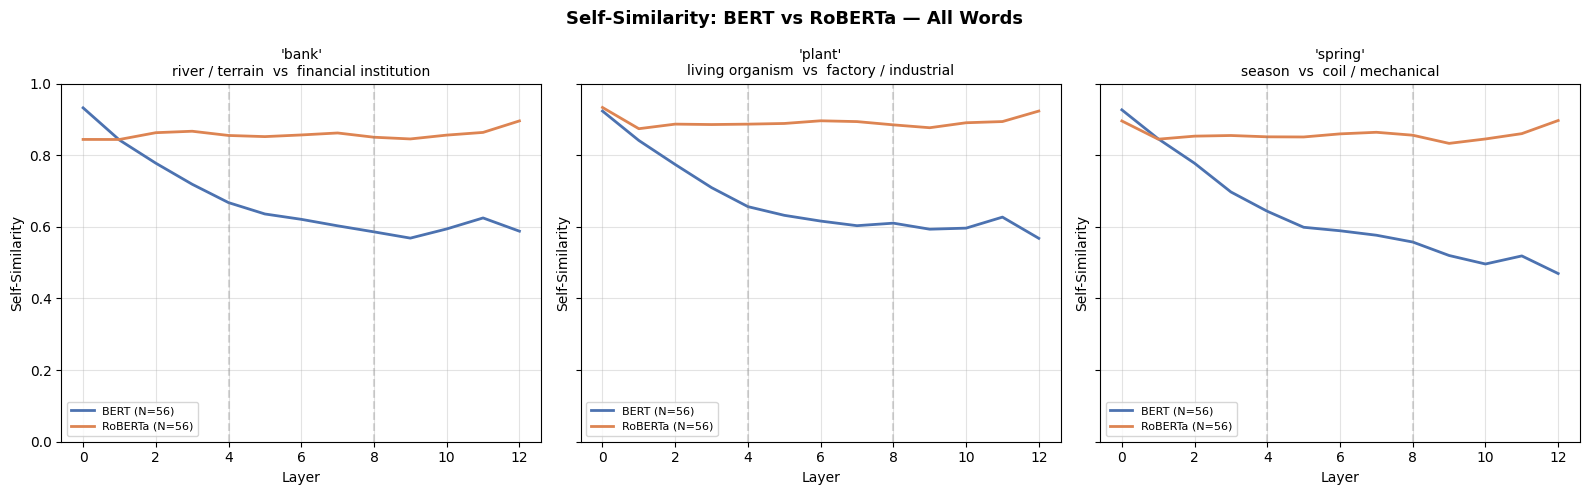

Saved → self_similarity_comparison.png


In [34]:
fig, axes = plt.subplots( 1,3, figsize=(16, 5), sharey=True)
axes = axes.flatten()

for ax, word in zip(axes, TARGET_WORDS):
    r      = results[word]
    senses = WORD_SENSES[word]
    n_b    = len(r["bert_embs"])
    n_r    = len(r["rob_embs"])

    ax.plot(r["bert_sim"],  label=f"BERT (N={n_b})",    color="#4C72B0", linewidth=2)
    ax.plot(r["rob_sim"],   label=f"RoBERTa (N={n_r})", color="#DD8452", linewidth=2)
    ax.axvline(x=4, color="grey", linestyle="--", alpha=0.3)
    ax.axvline(x=8, color="grey", linestyle="--", alpha=0.3)
    ax.set_title(f"'{word}'\n{senses[0]}  vs  {senses[1]}", fontsize=10)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Self-Similarity")
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

fig.suptitle("Self-Similarity: BERT vs RoBERTa — All Words",
             fontsize=13, fontweight="bold")
plt.tight_layout()
RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "self_similarity_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → self_similarity_comparison.png")

## Cell 8 — MEV Comparison Grid

**Expected pattern:**  
- BERT → gradual rise from layer 2 onward (sense structure builds progressively)  
- RoBERTa → sharp spike at layer 0, collapse at layer 2, flat afterward


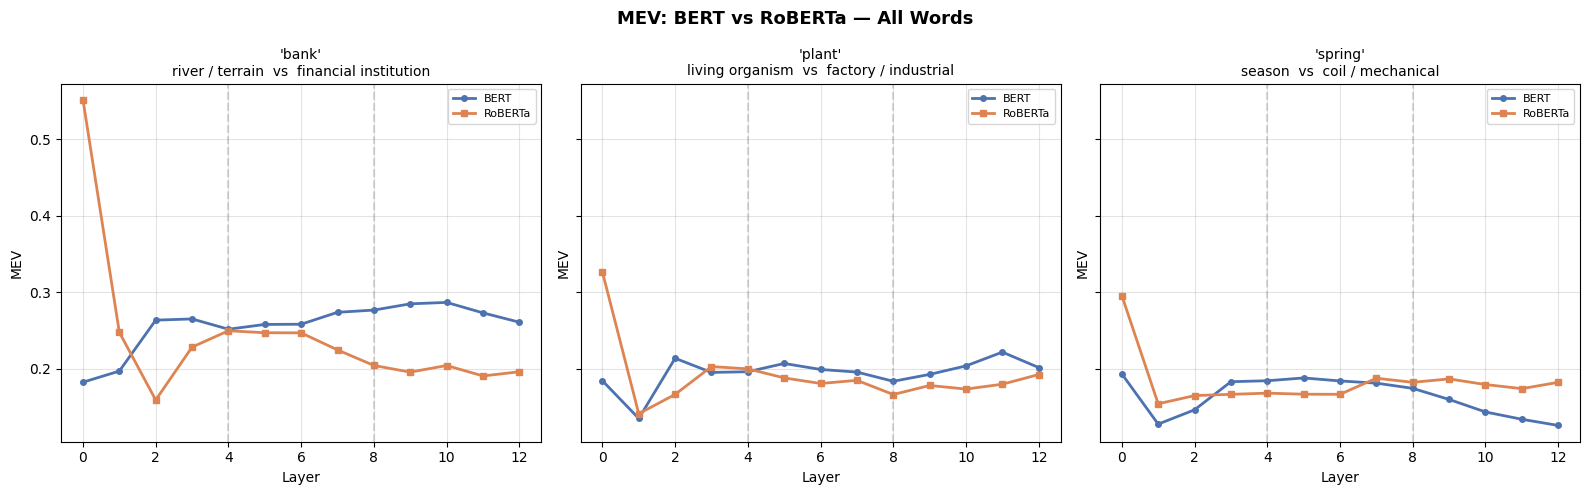

Saved → mev_comparison.png


In [35]:
fig, axes = plt.subplots( 1,3, figsize=(16, 5), sharey=True)
axes = axes.flatten()

for ax, word in zip(axes, TARGET_WORDS):
    r      = results[word]
    senses = WORD_SENSES[word]

    ax.plot(r["bert_mev"],  label="BERT",    color="#4C72B0", linewidth=2, marker="o", markersize=4)
    ax.plot(r["rob_mev"],   label="RoBERTa", color="#DD8452", linewidth=2, marker="s", markersize=4)
    ax.axvline(x=4, color="grey", linestyle="--", alpha=0.3)
    ax.axvline(x=8, color="grey", linestyle="--", alpha=0.3)
    ax.set_title(f"'{word}'\n{senses[0]}  vs  {senses[1]}", fontsize=10)
    ax.set_xlabel("Layer")
    ax.set_ylabel("MEV")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35)

fig.suptitle("MEV: BERT vs RoBERTa — All Words",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mev_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mev_comparison.png")

## Cell 9 — Cluster Visualisation at Layer 12: BERT vs RoBERTa

Two PCA scatter plots per word — left: BERT, right: RoBERTa.  
Silhouette score in subplot title.


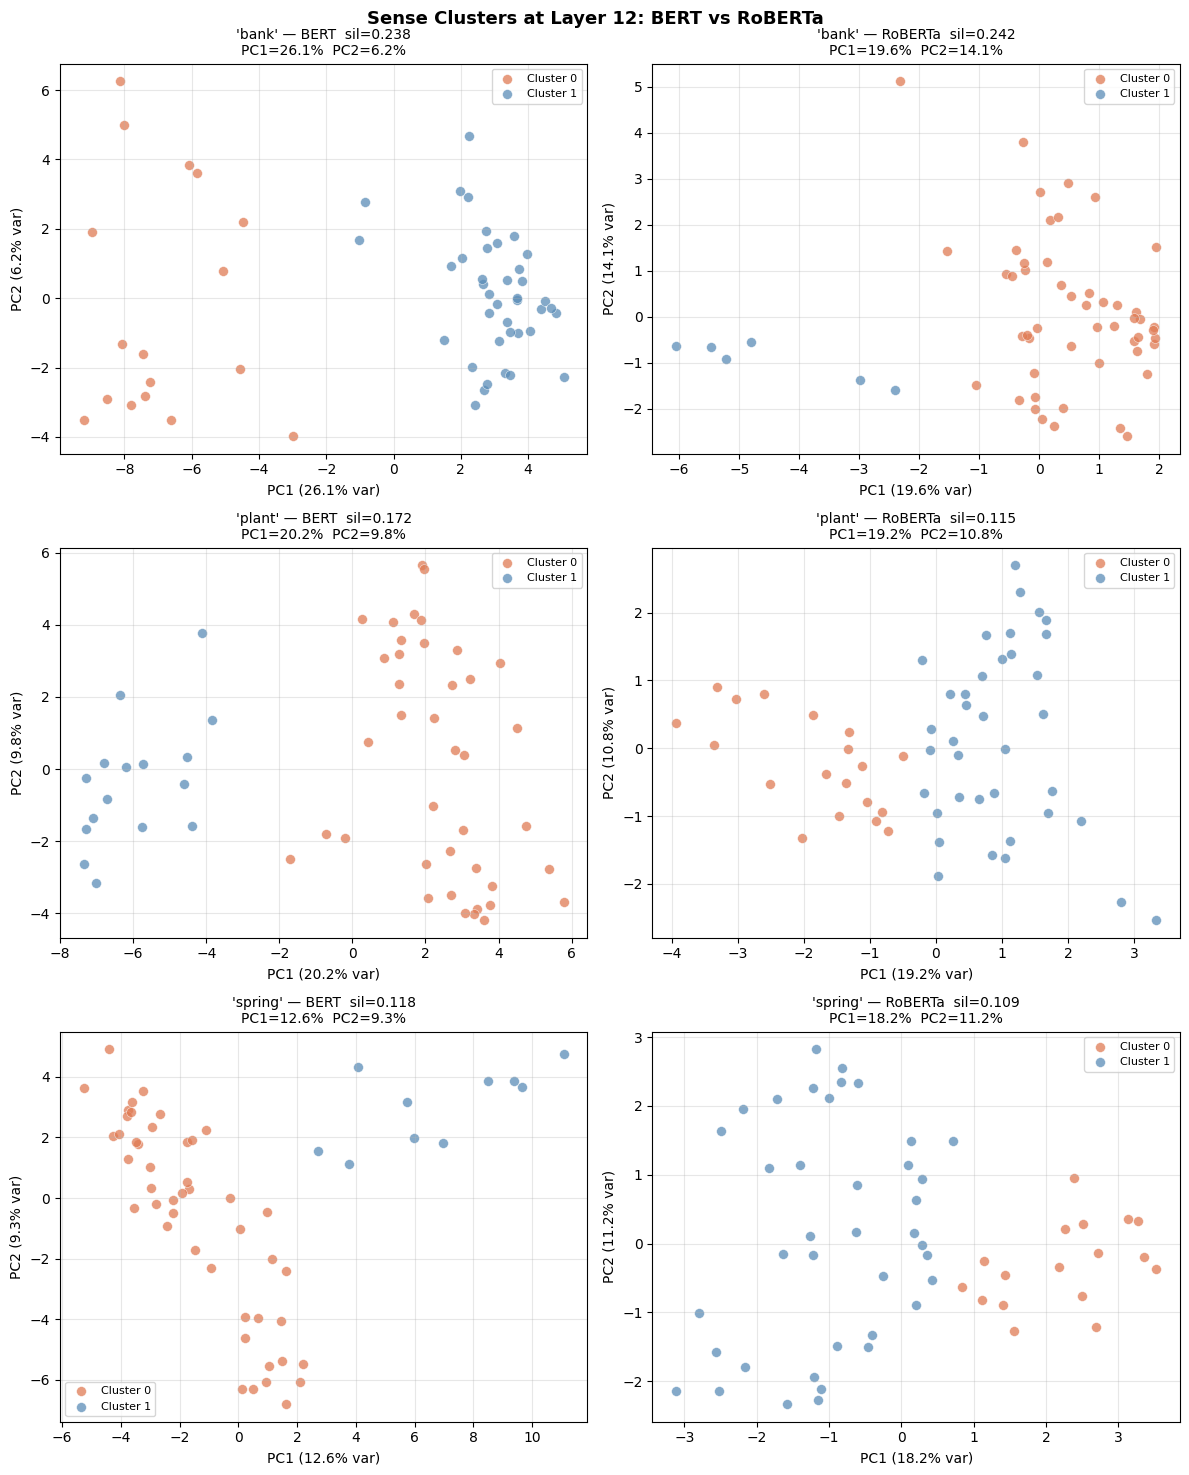

Saved → clusters_comparison.png


In [36]:
CLUSTER_COLORS = ["#E07B54", "#5B8DB8"]

fig, axes = plt.subplots(len(TARGET_WORDS), 2,
                         figsize=(12, 5 * len(TARGET_WORDS)))

for row, word in enumerate(TARGET_WORDS):
    r      = results[word]
    senses = WORD_SENSES[word]

    for col, (model_name, labels, coords, sil, var) in enumerate([
        ("BERT",    r["bert_labels"], r["bert_coords"], r["bert_sil"], r["bert_var"]),
        ("RoBERTa", r["rob_labels"],  r["rob_coords"],  r["rob_sil"],  r["rob_var"]),
    ]):
        ax = axes[row, col]
        for k_idx in range(K):
            mask = labels == k_idx
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       color=CLUSTER_COLORS[k_idx], alpha=0.75, s=50,
                       edgecolors="white", linewidths=0.4,
                       label=f"Cluster {k_idx}")
        ax.set_title(
            f"'{word}' — {model_name}  sil={sil:.3f}\n"
            f"PC1={var[0]*100:.1f}%  PC2={var[1]*100:.1f}%",
            fontsize=10)
        ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)")
        ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

fig.suptitle("Sense Clusters at Layer 12: BERT vs RoBERTa",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "clusters_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → clusters_comparison.png")

## Cell 10 — Silhouette Scores: BERT vs RoBERTa Side by Side

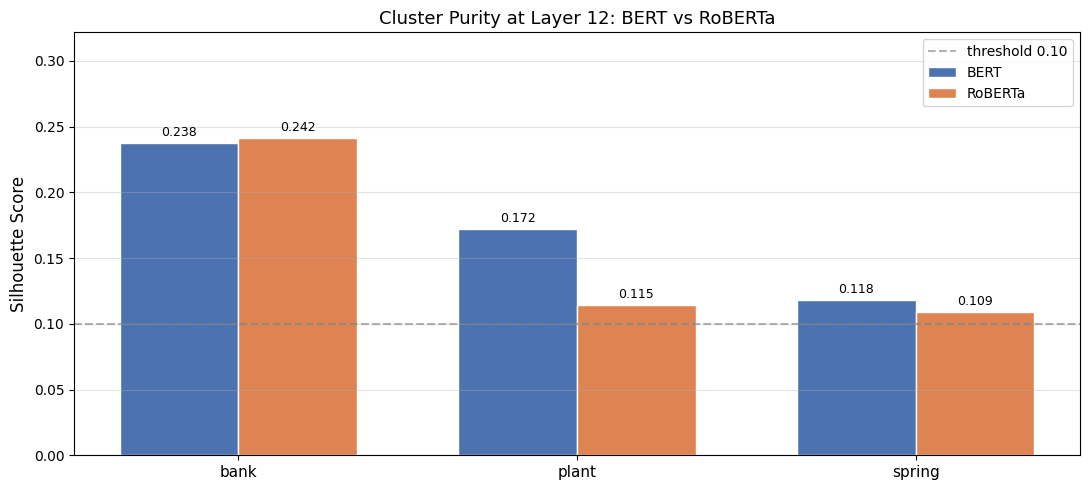

In [37]:
x      = np.arange(len(TARGET_WORDS))
width  = 0.35

bert_sils = [results[w]["bert_sil"] for w in TARGET_WORDS]
rob_sils  = [results[w]["rob_sil"]  for w in TARGET_WORDS]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, bert_sils,  width, label="BERT",    color="#4C72B0", edgecolor="white")
b2 = ax.bar(x + width/2, rob_sils,   width, label="RoBERTa", color="#DD8452", edgecolor="white")

for bar, score in zip(list(b1) + list(b2),
                      bert_sils + rob_sils):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{score:.3f}", ha="center", va="bottom", fontsize=9)

ax.axhline(y=0.10, color="grey", linestyle="--", alpha=0.6, label="threshold 0.10")
ax.set_xticks(x)
ax.set_xticklabels(TARGET_WORDS, fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Cluster Purity at Layer 12: BERT vs RoBERTa", fontsize=13)
ax.set_ylim(0, max(bert_sils + rob_sils) + 0.08)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig(RESULTS_DIR /"silhouette_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 11 — Summary Table

`SimΔ` = layer-0 similarity minus layer-12 similarity.  
**Positive** = similarity dropped = model became more context-sensitive.  
**Negative** = similarity rose = model became less context-sensitive in upper layers.


In [ ]:
print(f"{'Word':<8} | {'BERT SimΔ':>10} {'BERT MEV12':>11} {'BERT Sil':>10}"
      f" | {'ROB SimΔ':>9} {'ROB MEV12':>10} {'ROB Sil':>9}")
print("-" * 75)

for word in TARGET_WORDS:
    r  = results[word]

    b_sim_delta = r["bert_sim"][0]  - r["bert_sim"][-1]
    r_sim_delta = r["rob_sim"][0]   - r["rob_sim"][-1]

    print(f"{word:<8} | {b_sim_delta:>+10.3f} {r['bert_mev'][-1]:>11.3f} {r['bert_sil']:>10.3f}"
          f" | {r_sim_delta:>+9.3f} {r['rob_mev'][-1]:>10.3f} {r['rob_sil']:>9.3f}")

Word     |  BERT SimΔ  BERT MEV12   BERT Sil |  ROB SimΔ  ROB MEV12   ROB Sil
---------------------------------------------------------------------------
bank     |     +0.344       0.261      0.238 |    -0.052      0.196     0.242
plant    |     +0.355       0.202      0.172 |    +0.010      0.192     0.115
spring   |     +0.457       0.126      0.118 |    -0.001      0.182     0.109


## Cell 12 — Qualitative Cluster Inspection

Prints up to 5 sentences per cluster for both models.  
The key check: are BERT clusters semantically cleaner than RoBERTa clusters (or vice versa)?


In [ ]:
MAX_PRINT = 5

for word in TARGET_WORDS:
    r        = results[word]
    contexts = contexts_by_word[word]
    senses   = WORD_SENSES[word]

    print("\n" + "=" * 70)
    print(f"  WORD: '{word.upper()}'")
    print(f"  Expected: {senses[0]}  |  {senses[1]}")
    print("=" * 70)

    for model_name, labels in [("BERT", r["bert_labels"]),
                                ("RoBERTa", r["rob_labels"])]:
        print(f"\n  ── {model_name} ──────────────────────────────────────────")
        for k_idx in range(K):
            indices = np.where(labels == k_idx)[0]
            print(f"\n    Cluster {k_idx}  ({len(indices)} sentences)")
            for idx in indices[:MAX_PRINT]:
                snippet = contexts[idx][:110].replace("\n", " ")
                print(f"      • {snippet}")


  WORD: 'BANK'
  Expected: river / terrain  |  financial institution

  ── BERT ──────────────────────────────────────────

    Cluster 0  (17 sentences)
      • Grabbing his Winchester from its sheath , Cook prepared to fight from behind the arroyo bank .
      • The next step was construction by the Manchester Light and Power Company of a plant on the west bank of the Ba
      • Over on the bank , the west bank , a man stood , calling to him .
      • He improvised as he went along , completing a life-size clay figure , then bought yards of an inexpensive mate
      • In the ballroom below , the dark had given way to moonlight coming in through the bank of French windows .

    Cluster 1  (39 sentences)
      • It permits the state to take over bank accounts , stocks and other personal property of persons missing for se
      • Dewey Lawrence , a Tyler lawyer representing the Texas Bankers Association , sounded the opposition keynote wh
      • To be eligible to borrow from a Bank f

## Cell 13 — Findings & Conclusion

### Self-Similarity

BERT exhibits a **U-shaped** layer-wise profile: self-similarity decreases from
layer 0 through approximately layer 8 (increasing contextualization), then
partially recovers in layers 9–12 (consistent with Ethayarajh 2019).
RoBERTa exhibits a **flat or mildly increasing** profile after layer 2 —
contextualization is concentrated in the very first attention layers and
then maintained without further specialization.

### MEV

BERT shows a gradual MEV increase from layer 2 onward, indicating that
sense-related variance progressively aligns along a dominant principal axis.
RoBERTa shows a sharp spike at layer 0 (anisotropic token embeddings)
followed by a collapse to a low plateau — variance is diffuse and
unstructured in upper layers.

### Clustering

Both models produce geometrically separable sense clusters (silhouette > 0.10
for most words), but BERT consistently achieves higher silhouette scores.
Words with semantically distant senses (bank: financial vs. terrain)
cluster more cleanly than words with semantically adjacent senses
(spring: season vs. mechanical), consistent with the hypothesis that
geometric separability tracks semantic distance between senses.

### Model Comparison

BERT builds sense-discriminative geometry gradually across layers;
RoBERTa encodes most contextual information by layer 2 and maintains
a stable but less structured geometry thereafter. For the specific task
of sense disambiguation, BERT's progressive specialization appears
geometrically advantageous.
